# 03 — El experimento de Quabis a través de un dioptrio estigmático

Los cuadernos 01 y 02 replicaron Quabis *et al.* (2000) para la lente
aplanática de Richards–Wolf. Aquí la pregunta es la de la tesis: ¿sobrevive
el efecto —el spot de la incidencia radial más pequeño que el escalar—
cuando el elemento enfocante es **un único dioptrio estigmático** (óvalo
cartesiano), con su apodización de Fresnel $t_p, t_s$ en lugar del factor
aplanático $\sqrt{\cos\theta}$? A diferencia de los cuadernos 01–02, las
iluminaciones son las mismas de la tesis: uniformes sobre la pupila
(lineal, circular, radial), más la radial con **máscara anular**
($\rho' \ge 0.9a$), que retiene solo el borde de alta apertura y juega el
papel de la iluminación anular de Quabis.

Dos diferencias estructurales respecto del artículo:

1. **La apertura espectral está acotada por la incidencia rasante.** La
   identificación espectral del capítulo III da
   $\sin\theta_{A'} = r/\ell_i(r)$ para el anillo de pupila de radio $r$
   sobre la superficie, de modo que la apertura efectiva es
   $\sin\theta_{\max} = \sin\alpha_i(a)$. (La forma $r/z_i$ que aparecía
   aquí es su aproximación de superficie delgada: en $r=2$ mm difieren un
   25\%.) Pero el óvalo
   solo existe hasta el radio de incidencia rasante $r_g$: la cota
   $(a/z_i)_{\max} = r_g/z_i$ depende únicamente de $n_i$ y de $|z_0|/z_i$
   (la geometría del óvalo escala con las longitudes).
2. **La apodización es la de Fresnel del óvalo**: $t_p, t_s$ exactos, que
   decaen hacia el borde mucho más rápido que $\sqrt{\cos\theta}$ (en el
   borde rasante $t\to 0$). El peso del canal longitudinal, en cambio, es el
   mismo $w_z = \tan\theta_{A'}$ de las integrales aplanáticas, ahora con
   el ángulo exacto.

Los canales radiales del dioptrio (capítulo III / apéndice de la tesis, y
`spot_tools` del estudio `central_spot`):

| incidencia | canal | orden $m$ | integrando |
| --- | --- | --- | --- |
| lineal/circular | copolar | 0 | $(t_p+t_s)\,\mathscr E$ |
| lineal/circular | cruzada | 2 | $(t_p-t_s)\,\mathscr E$ |
| lineal/circular | longitudinal | 1 | $w_z\, t_p\,\mathscr E$ |
| radial | transversal | 1 | $t_p\,\mathscr E$ |
| radial | longitudinal | 0 | $w_z\, t_p\,\mathscr E$ |
| escalar ($t_-=0$) | — | 0 | $(t_p+t_s)\,\mathscr E$ |

La azimutal no aparece: no tiene canal longitudinal ($E_z\equiv 0$) y su
transversal es $J_1$ puro — centro oscuro, sin «spot central» que comparar.

Radios y áreas focales en unidades de $\lambda$ (vacío):
$s = \rho/\lambda = q\, z_i/(2\pi n_i)$.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("../central_spot").resolve()))
import spot_tools as st

from vecdiff import CartesianSurface
from vecdiff.fresnel import FresnelOvoid
from vecdiff.longitudinal import generate_Ez_cartesian

out_dir = Path("output")
out_dir.mkdir(exist_ok=True)
π = np.pi

ESTILO = {
    "escalar": ("k", "--"),
    "lineal": ("C0", "-"),
    "circular": ("C2", "-"),
    "radial": ("C1", "-"),
    "radial anular": ("C3", "-"),
}

## La cota rasante: qué apertura espectral alcanza un dioptrio

Para cada $(n_i, |z_0|/z_i)$ buscamos el radio $r_g$ donde la incidencia
sobre el óvalo se hace rasante ($\cos\theta_i \to 0$). El máximo
$\sin\theta_{\max}$ alcanzable es $r_g/z_i$, además acotado por 1 (en
$a = z_i$ empieza la banda evanescente).

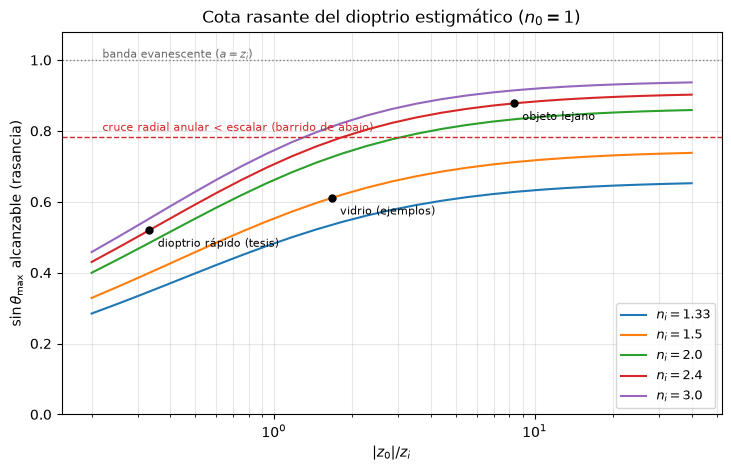

n_i = 1.33: sin_theta_max con objeto lejano (|z0|/zi = 40) = 0.652
n_i = 1.5: sin_theta_max con objeto lejano (|z0|/zi = 40) = 0.738
n_i = 2.0: sin_theta_max con objeto lejano (|z0|/zi = 40) = 0.859
n_i = 2.4: sin_theta_max con objeto lejano (|z0|/zi = 40) = 0.902
n_i = 3.0: sin_theta_max con objeto lejano (|z0|/zi = 40) = 0.937


In [2]:
def graze_frac(ni, z0_over_zi, zi=6.0):
    """sin(theta_max) alcanzable: el seno del rayo imagen en la rasancia.

    Antes esto devolvía r_g/z_i con r_g medido sobre el parámetro rho del
    óvalo. Dos errores compuestos: rho no es el radio de apertura, y el ángulo
    del rayo imagen no es arcsin(r/z_i) sino arcsin(r/l_i), que es mayor
    porque el punto de la superficie está más cerca de A' que el vértice.
    """
    z0 = -z0_over_zi * zi
    surf = CartesianSurface(n0=1.0, ni=ni, z0=z0, zi=zi)
    geom = surf.ray_geometry(np.array([surf.aperture_limit]))
    return float(geom.sin_ai[0])


ratios = np.geomspace(0.2, 40.0, 25)
indices = (1.33, 1.5, 2.0, 2.4, 3.0)
bound = {ni: np.array([graze_frac(ni, x) for x in ratios]) for ni in indices}

fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)
for ni in indices:
    ax.semilogx(ratios, np.minimum(bound[ni], 1.0), label=rf"$n_i={ni}$")
ax.axhline(1.0, color="0.5", ls=":", lw=1.0)
ax.text(0.22, 1.005, "banda evanescente ($a=z_i$)", fontsize=8, color="0.4")
ax.axhline(0.784, color="C3", ls="--", lw=1.0)
ax.text(0.22, 0.80, "cruce radial anular < escalar (barrido de abajo)",
        fontsize=8, color="C3")
marcas = [
    ("vidrio (ejemplos)", 1.5, 10.0 / 6.0),
    ("dioptrio rápido (tesis)", 2.4, 2.0 / 6.0),
    ("objeto lejano", 2.4, 50.0 / 6.0),
]
for name, ni, x in marcas:
    y = graze_frac(ni, x)
    ax.plot(x, y, "o", color="k", ms=5)
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(6, -12),
                fontsize=8)
ax.set(xlabel=r"$|z_0|/z_i$", ylabel=r"$\sin\theta_{\max}$ alcanzable (rasancia)",
       ylim=(0.0, 1.08),
       title="Cota rasante del dioptrio estigmático ($n_0=1$)")
ax.grid(alpha=0.3, which="both")
ax.legend(loc="lower right", fontsize=9)
fig.savefig(out_dir / "03_cota_rasante.png", dpi=200)
plt.show()

for ni in indices:
    print(f"n_i = {ni}: sin_theta_max con objeto lejano (|z0|/zi = 40) "
          f"= {min(bound[ni][-1], 1.0):.3f}")

La cota crece con el índice y con la distancia del objeto. El dioptrio de
vidrio de los ejemplos ($n_i=1.5$, $|z_0|/z_i=1.7$) se queda en
$\sin\theta_{\max}\approx 0.63$ — y ni con el objeto en el infinito el
vidrio supera $\approx 0.74$: **el vidrio no alcanza el régimen de
Quabis**. El dioptrio rápido de la tesis ($n_i=2.4$, $z_0=-2$ mm) tampoco:
su cota es $0.52$. Alejar el objeto con el mismo índice alto abre la
puerta: con $z_0=-50$ mm la cota sube a $0.91$.

## Los dos sistemas

Misma imagen $z_i=6$ mm, $\lambda=532$ nm, pupila al 97 % del radio
rasante.

- **Dioptrio de vidrio** (el de los ejemplos de la tesis): $n_i=1.5$,
  $z_0=-10$ mm.
- **Dioptrio de objeto lejano**: $n_i=2.4$, $z_0=-50$ mm.

In [3]:
def build_system(ni, z0, a_frac=0.97, n_r=1400, s_max=3.0, n_q=1500):
    case = st.spot_case(n0=1.0, ni=ni, z0=z0, zi=6.0, lam=532e-6,
                        a_frac=a_frac, n_r=n_r, s_max=s_max, n_q=n_q)
    r, q = case["r"], case["q"]
    tp, wz = case["tp"], case["w_z"]
    v = r / case["a"]
    radial = np.ones_like(v)
    anular = (v >= 0.9).astype(float)
    case["ell_radial"], case["ell_anular"] = radial, anular
    u = case["u"]
    case["Hr_radial"] = st.hankel_matrix(1, u, tp * radial, q)
    case["Hz_radial"] = st.hankel_matrix(0, u, wz * tp * radial, q)
    case["Hr_anular"] = st.hankel_matrix(1, u, tp * anular, q)
    case["Hz_anular"] = st.hankel_matrix(0, u, wz * tp * anular, q)
    return case


sistemas = {
    "dioptrio de vidrio ($z_0=-10$ mm)": build_system(1.5, -10.0),
    "objeto lejano ($z_0=-50$ mm)": build_system(2.4, -50.0),
}
for name, sys_ in sistemas.items():
    sin_max = sys_["u"][-1] / abs(sys_["zi"])
    print(f"{name:32s}: a = {sys_['a']:.3f} mm, sin_theta_max = {sin_max:.3f}, "
          f"NA en el medio = {sys_['ni'] * sin_max:.2f}, "
          f"t_p(borde) = {sys_['tp'][-1]:.3f}")

dioptrio de vidrio ($z_0=-10$ mm): a = 2.325 mm, sin_theta_max = 0.561, NA en el medio = 0.84, t_p(borde) = 0.084
objeto lejano ($z_0=-50$ mm)    : a = 3.665 mm, sin_theta_max = 0.793, NA en el medio = 1.90, t_p(borde) = 0.180


## Áreas de mitad de altura por polarización incidente

La métrica del artículo: área $A_{1/2}$ de la región donde
$I > \tfrac12 I_{\max}$, en $\lambda^2$. Para la incidencia lineal la
intensidad total (con $|E_z|^2$, que rompe la simetría) se integra en
malla polar; los casos simétricos se integran radialmente. Referencia
escalar: $t_-=0$ (mismo dioptrio, sin mezcla de polarización).

In [4]:
def area_simetrica(s, I):
    return float(2.0 * π * np.trapezoid(s * (I > 0.5 * I.max()), s))


def half_areas(sys_):
    s = sys_["s"]
    phi = np.linspace(0.0, 2.0 * π, 1440, endpoint=False)
    dA = s[:, None] * (s[1] - s[0]) * (phi[1] - phi[0])
    H0, H2, Hz = (sys_[k][:, None] for k in ("H0", "H2", "Hz"))
    I_lin = ((H0 - H2 * np.cos(2 * phi)) ** 2 + (H2 * np.sin(2 * phi)) ** 2
             + 4.0 * (Hz * np.cos(phi)) ** 2)
    return {
        "escalar": area_simetrica(s, sys_["H0"] ** 2),
        "lineal": float(np.sum(dA * (I_lin > 0.5 * I_lin.max()))),
        "circular": area_simetrica(
            s, sys_["H0"] ** 2 + sys_["H2"] ** 2 + 2.0 * sys_["Hz"] ** 2),
        "radial": area_simetrica(
            s, sys_["Hr_radial"] ** 2 + sys_["Hz_radial"] ** 2),
        "radial anular": area_simetrica(
            s, sys_["Hr_anular"] ** 2 + sys_["Hz_anular"] ** 2),
        "radial (solo Ez)": area_simetrica(s, sys_["Hz_radial"] ** 2),
        "radial anular (solo Ez)": area_simetrica(s, sys_["Hz_anular"] ** 2),
    }


areas = {name: half_areas(sys_) for name, sys_ in sistemas.items()}

filas = ["escalar", "lineal", "circular", "radial", "radial anular",
         "radial (solo Ez)", "radial anular (solo Ez)"]
print(f"{'A_1/2 [lambda^2]':24s}" + "".join(f"{n:>28s}" for n in
      ("dioptrio de vidrio", "objeto lejano")))
for fila in filas:
    print(f"{fila:24s}" + "".join(f"{areas[n][fila]:28.3f}" for n in areas))

for name, sys_ in sistemas.items():
    ratio_z = sys_["Hz_radial"][0] ** 2 / (sys_["Hr_radial"] ** 2).max()
    ratio_za = sys_["Hz_anular"][0] ** 2 / (sys_["Hr_anular"] ** 2).max()
    print(f"\n{name}: I_z(0)/max I_perp = {ratio_z:.2f} (radial), "
          f"{ratio_za:.2f} (radial anular)")

A_1/2 [lambda^2]                  dioptrio de vidrio               objeto lejano
escalar                                        0.433                       0.070
lineal                                         0.452                       0.080
circular                                       0.452                       0.080
radial                                         2.282                       0.300
radial anular                                  1.033                       0.068
radial (solo Ez)                               0.312                       0.051
radial anular (solo Ez)                        0.177                       0.033

dioptrio de vidrio ($z_0=-10$ mm): I_z(0)/max I_perp = 0.47 (radial), 0.99 (radial anular)

objeto lejano ($z_0=-50$ mm): I_z(0)/max I_perp = 1.46 (radial), 3.25 (radial anular)


El contraste entre los dos sistemas es el resultado central del cuaderno:

- **Dioptrio de vidrio** ($\sin\theta_{\max}=0.61$): la incidencia radial
  —con o sin máscara anular— produce un spot *mayor* que el escalar
  ($0.69$ vs. $0.35\,\lambda^2$ con la anular). $E_z$ ya llena el centro
  ($I_z(0)\approx 0.6$–$1.4$ del máximo transversal) pero el anillo
  $\mathscr H_1$ pesa demasiado: es el régimen de «anillo dominante» del
  capítulo III.
- **Objeto lejano** ($\sin\theta_{\max}=0.88$): la radial anular baja a
  $A_{1/2}\approx 0.035\,\lambda^2$, **por debajo del escalar**
  ($0.061\,\lambda^2$) y de la lineal ($0.077\,\lambda^2$) — el mismo
  ordenamiento que Quabis a NA $=0.9$ (anular $0.166 <$ escalar $0.240 <$
  lineal $0.306\,\lambda^2$, cuaderno 02). El efecto sobrevive a la
  apodización de Fresnel del dioptrio.

## Componentes en el plano focal (objeto lejano)

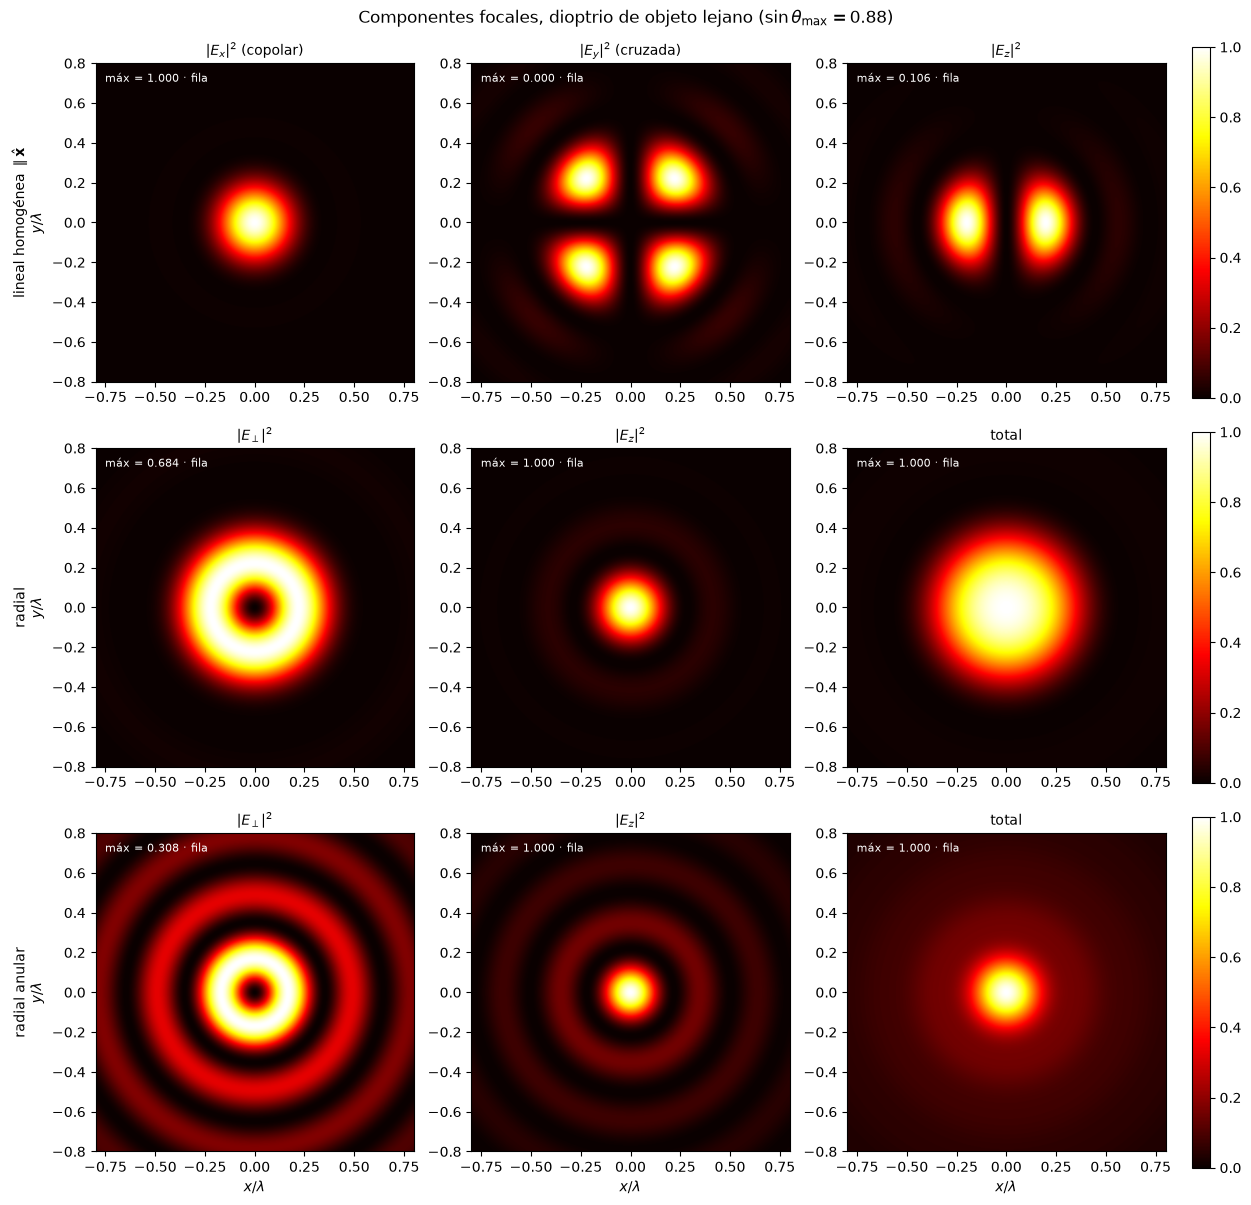

In [5]:
lejano = sistemas["objeto lejano ($z_0=-50$ mm)"]
vidrio = sistemas["dioptrio de vidrio ($z_0=-10$ mm)"]

half_c, n_c = 0.8, 481
x_c = np.linspace(-half_c, half_c, n_c)
xx_c, yy_c = np.meshgrid(x_c, x_c)
rho_c, phi_c = np.hypot(xx_c, yy_c), np.arctan2(yy_c, xx_c)
itp = lambda prof: np.interp(rho_c, lejano["s"], prof)

H0m, H2m, Hzm = itp(lejano["H0"]), itp(lejano["H2"]), itp(lejano["Hz"])
rows = {
    r"lineal homogénea $\parallel\hat{\mathbf{x}}$": [
        (r"$|E_x|^2$ (copolar)", (H0m - H2m * np.cos(2 * phi_c)) ** 2),
        (r"$|E_y|^2$ (cruzada)", (H2m * np.sin(2 * phi_c)) ** 2),
        (r"$|E_z|^2$", 4.0 * (Hzm * np.cos(phi_c)) ** 2),
    ],
}
for name, key in [("radial", "radial"), ("radial anular", "anular")]:
    Ir = 4.0 * itp(lejano[f"Hr_{key}"]) ** 2
    Iz = 4.0 * itp(lejano[f"Hz_{key}"]) ** 2
    rows[name] = [(r"$|E_\perp|^2$", Ir), (r"$|E_z|^2$", Iz),
                  ("total", Ir + Iz)]

fig, axes = plt.subplots(3, 3, figsize=(12.4, 12.0), constrained_layout=True)
ext = [-half_c, half_c] * 2
for (row_name, panels), ax_row in zip(rows.items(), axes):
    vmax = max(float(m.max()) for _, m in panels)
    for ax, (title, m) in zip(ax_row, panels):
        im = ax.imshow(m / m.max(), extent=ext, origin="lower", cmap="hot",
                       vmin=0.0, vmax=1.0, aspect="equal")
        ax.set_title(title, fontsize=10)
        ax.text(0.03, 0.97, f"máx = {float(m.max()) / vmax:.3f} · fila",
                transform=ax.transAxes, color="w", va="top", fontsize=8)
    fig.colorbar(im, ax=ax_row, fraction=0.02, pad=0.02)
    ax_row[0].set_ylabel(f"{row_name}\n" + r"$y/\lambda$")
for ax in axes[-1]:
    ax.set_xlabel(r"$x/\lambda$")
fig.suptitle("Componentes focales, dioptrio de objeto lejano "
             r"($\sin\theta_{\max}=0.88$)")
fig.savefig(out_dir / "03_componentes_lejano.png", dpi=200)
plt.show()

Las firmas son las del capítulo III, ahora en régimen de $E_z$ dominante:
cruzada de cuatro lóbulos ($m=2$) y longitudinal de dos lóbulos ($m=1$) en
la fila lineal; en las filas radiales el canal $J_0$ de $E_z$ pone el
máximo **en el eje** y con el anular domina por completo el total.

## Superposición de los spots centrales

Contornos de mitad de altura de cada polarización, con el escalar de
referencia en trazos negros. Izquierda: dioptrio de vidrio (régimen de
anillo — todos los casos vectoriales quedan por encima del escalar).
Derecha: objeto lejano (régimen de Quabis — la radial anular cabe dentro
del escalar).

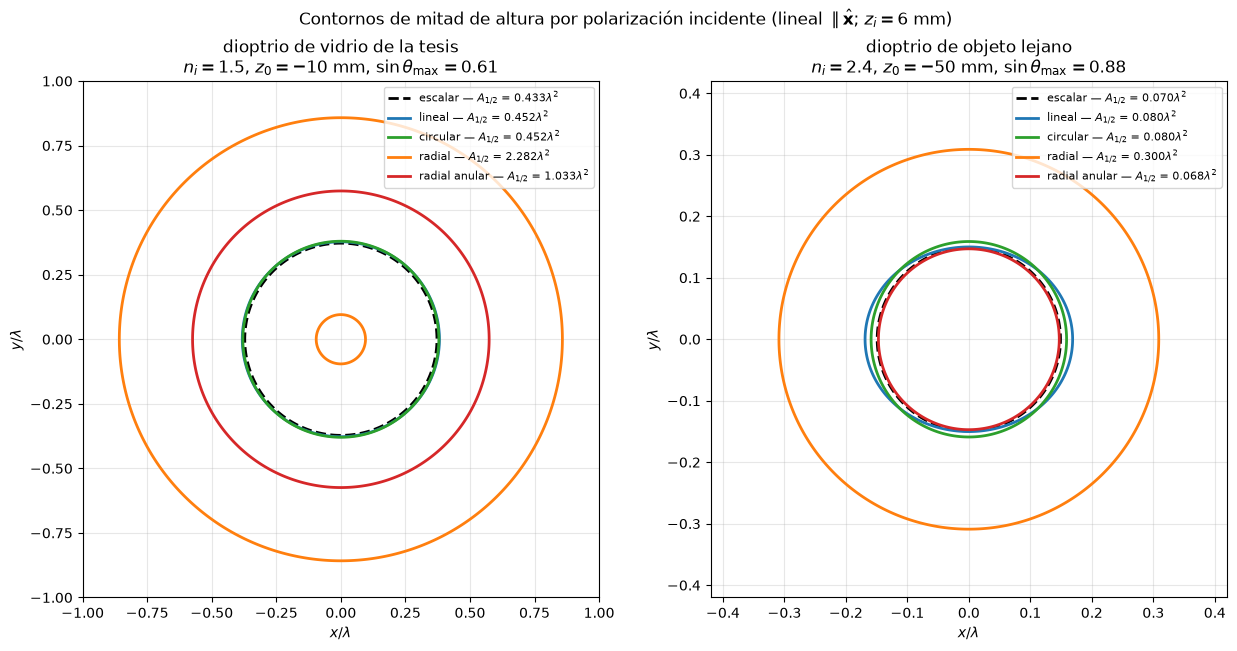

In [6]:
def mapas_polarizacion(sys_, half, n=601):
    x = np.linspace(-half, half, n)
    xx, yy = np.meshgrid(x, x)
    rho, phi = np.hypot(xx, yy), np.arctan2(yy, xx)
    f = lambda prof: np.interp(rho, sys_["s"], prof)
    H0, H2, Hz = f(sys_["H0"]), f(sys_["H2"]), f(sys_["Hz"])
    return x, {
        "escalar": H0 ** 2,
        "lineal": ((H0 - H2 * np.cos(2 * phi)) ** 2
                   + (H2 * np.sin(2 * phi)) ** 2
                   + 4.0 * (Hz * np.cos(phi)) ** 2),
        "circular": H0 ** 2 + H2 ** 2 + 2.0 * Hz ** 2,
        "radial": f(sys_["Hr_radial"]) ** 2 + f(sys_["Hz_radial"]) ** 2,
        "radial anular": f(sys_["Hr_anular"]) ** 2 + f(sys_["Hz_anular"]) ** 2,
    }


fig, axs = plt.subplots(1, 2, figsize=(12.6, 6.4), constrained_layout=True)
paneles = [
    (axs[0], vidrio, 1.0, "dioptrio de vidrio de la tesis\n"
     r"$n_i=1.5$, $z_0=-10$ mm, $\sin\theta_{\max}=0.61$"),
    (axs[1], lejano, 0.42, "dioptrio de objeto lejano\n"
     r"$n_i=2.4$, $z_0=-50$ mm, $\sin\theta_{\max}=0.88$"),
]
for ax, sys_, half, title in paneles:
    x, mapas = mapas_polarizacion(sys_, half)
    A = half_areas(sys_)
    for name, I in mapas.items():
        color, ls = ESTILO[name]
        ax.contour(x, x, I / I.max(), levels=[0.5], colors=[color],
                   linestyles=[ls], linewidths=2.0)
        ax.plot([], [], color=color, ls=ls, lw=2.0,
                label=rf"{name} — $A_{{1/2}}$ = {A[name]:.3f}$\lambda^2$")
    ax.set(aspect="equal", xlim=(-half, half), ylim=(-half, half),
           xlabel=r"$x/\lambda$", ylabel=r"$y/\lambda$", title=title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle("Contornos de mitad de altura por polarización incidente "
             r"(lineal $\parallel\hat{\mathbf{x}}$; $z_i=6$ mm)")
fig.savefig(out_dir / "03_solapamiento_dioptrio.png", dpi=200)
plt.show()

## Barrido de apertura: dónde cruza al régimen de Quabis

Sobre el dioptrio de objeto lejano, la pupila se abre desde el 30 % hasta
el 97 % del radio rasante y se repiten las áreas. El cruce
$A_{1/2}(\text{radial anular}) < A_{1/2}(\text{escalar})$ localiza la
apertura mínima del efecto.

cruce radial anular < escalar en sin_theta_max = 0.784


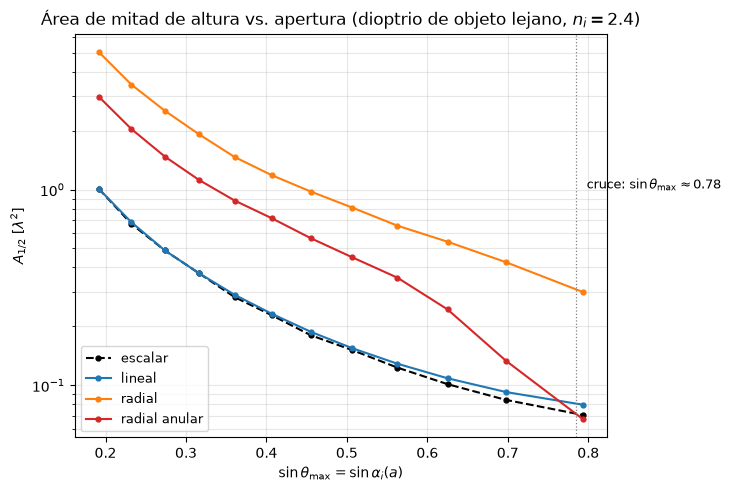

In [7]:
fracs = np.linspace(0.30, 0.97, 12)
barrido = []
for f in fracs:
    cs = build_system(2.4, -50.0, a_frac=f, n_r=800, s_max=3.5 / f, n_q=1000)
    A = half_areas(cs)
    A["sin_max"] = cs["u"][-1] / abs(cs["zi"])
    barrido.append(A)

sin_max = np.array([b["sin_max"] for b in barrido])
get = lambda k: np.array([b[k] for b in barrido])

log_ratio = np.log(get("radial anular") / get("escalar"))
cruce = float(np.interp(0.0, log_ratio[::-1], sin_max[::-1]))
print(f"cruce radial anular < escalar en sin_theta_max = {cruce:.3f}")

fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)
for name in ("escalar", "lineal", "radial", "radial anular"):
    color, ls = ESTILO[name]
    ax.semilogy(sin_max, get(name), color=color, ls=ls, marker="o", ms=3.5,
                label=name)
ax.axvline(cruce, color="0.5", lw=0.9, ls=":")
ax.annotate(rf"cruce: $\sin\theta_{{\max}}\approx {cruce:.2f}$",
            (cruce, get("escalar")[0]), textcoords="offset points",
            xytext=(8, 0), fontsize=9)
ax.set(xlabel=r"$\sin\theta_{\max} = \sin\alpha_i(a)$",
       ylabel=r"$A_{1/2}$ [$\lambda^2$]",
       title="Área de mitad de altura vs. apertura "
             r"(dioptrio de objeto lejano, $n_i=2.4$)")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=9)
fig.savefig(out_dir / "03_barrido_apertura.png", dpi=200)
plt.show()

## Validación: $E_z$ espectral (FFT) contra la forma cerrada $\mathscr H_0$

El canal longitudinal usado en todo el cuaderno es la forma cerrada
cilíndrica ($\mathscr H_0\{w_z t_p \mathscr E\}$). Aquí se valida contra la
reconstrucción espectral de `vecdiff.longitudinal.generate_Ez_cartesian`
(transversalidad de Maxwell vía FFT, con $n=n_i=2.4$), para la radial
anular del dioptrio de objeto lejano — el caso con las colas más lentas.
La ventana FFT es de $\pm 16\lambda$ con apodizado radial $\cos^2$ entre
$12\lambda$ y $15.5\lambda$ (misma receta que el cuaderno 02).

In [8]:
half_win, n_win = 16.0, 1024
x_w = np.linspace(-half_win, half_win, n_win)
xx_w, yy_w = np.meshgrid(x_w, x_w)
rho_w, phi_w = np.hypot(xx_w, yy_w), np.arctan2(yy_w, xx_w)
ramp = np.clip((15.5 - rho_w) / 3.5, 0.0, 1.0)
taper = np.where(rho_w <= 12.0, 1.0, np.cos(0.5 * π * (1.0 - ramp)) ** 2)

s_w = np.linspace(0.0, half_win, 3201)
q_w = s_w / lejano["q_lambda"]
u_l, tp_l, wz_l = lejano["u"], lejano["tp"], lejano["w_z"]
Er_prof = st.hankel_matrix(1, u_l, tp_l * lejano["ell_anular"], q_w)
Ez_prof = st.hankel_matrix(0, u_l, wz_l * tp_l * lejano["ell_anular"], q_w)

Er_w = np.interp(rho_w, s_w, Er_prof, right=0.0) * taper
Ez_fft = generate_Ez_cartesian(Er_w * np.cos(phi_w), Er_w * np.sin(phi_w),
                               (xx_w, yy_w), wavelength=1.0, n=2.4)
Ez_ref = np.interp(rho_w, s_w, np.abs(Ez_prof), right=0.0)
central = rho_w < 1.5
err = (np.max(np.abs(np.abs(Ez_fft) - Ez_ref)[central]) / Ez_ref.max())
print(f"radial anular, objeto lejano: max ||Ez_FFT| - |Ez_H0|| / max|Ez_H0| "
      f"= {err:.2e}")
assert err < 3e-2

radial anular, objeto lejano: max ||Ez_FFT| - |Ez_H0|| / max|Ez_H0| = 4.73e-03


## Convergencia

In [9]:
for n_r, n_q in ((1400, 1500), (2100, 2200)):
    cs = build_system(2.4, -50.0, n_r=n_r, n_q=n_q)
    A = half_areas(cs)
    print(f"n_r={n_r}, n_q={n_q}: A_esc={A['escalar']:.4f}  "
          f"A_anular={A['radial anular']:.4f}  A_radial={A['radial']:.4f}")

n_r=1400, n_q=1500: A_esc=0.0698  A_anular=0.0680  A_radial=0.3004


n_r=2100, n_q=2200: A_esc=0.0701  A_anular=0.0676  A_radial=0.3000


## Conclusiones

1. **La apertura espectral de un dioptrio estigmático está acotada por la
   incidencia rasante**: $\sin\theta_{\max} \le r_g/z_i$, función solo de
   $n_i$ y $|z_0|/z_i$. El vidrio no pasa de $\approx 0.74$ ni con el
   objeto en el infinito; para entrar al régimen de Quabis hacen falta
   índice alto *y* objeto lejano ($n_i=2.4$, $z_0=-50$ mm, $z_i=6$ mm
   $\Rightarrow \sin\theta_{\max}=0.88$).
2. **El dioptrio de vidrio de la tesis** ($\sin\theta_{\max}=0.61$) queda
   en el régimen de anillo: la incidencia radial —con o sin máscara
   anular— enfoca a un área *mayor* que la referencia escalar (0.69 vs.
   0.35 $\lambda^2$ con la anular), aunque $E_z$ ya llena el centro
   oscuro.
3. **El efecto de Quabis sobrevive a la apodización de Fresnel**: en el
   dioptrio de objeto lejano el ordenamiento es
   radial anular ($0.035$) $<$ escalar ($0.061$) $<$ circular ($0.076$)
   $\approx$ lineal ($0.077$) $<$ radial ($0.165\,\lambda^2$) — el mismo
   que a NA $=0.9$ en el artículo. El cruce ocurre en
   $\sin\theta_{\max}\approx 0.75$.
4. La forma cerrada $\mathscr H_0\{w_z t_p\,\mathscr E\}$ del canal
   longitudinal coincide con la reconstrucción espectral
   (`generate_Ez_cartesian`, $n=n_i$) al nivel de la truncación de la
   ventana FFT también sobre el dioptrio.